# Laboratorio 7 — Spark MLlib
## 07. Entrenamiento final y evaluación en 2026

Se responde la segunda pregunta del laboratorio con datos que ningún modelo vio: **¿qué tan bien puede estimarse el salario mensual de una persona asalariada con edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio?**

- **Configuraciones:** la de menor RMSE de validación de cada algoritmo (actividades 5 y 6).
- **Entrenamiento final:** los cuatro trimestres de 2025 (`data/processed/personas_2025.parquet`).
- **Prueba:** primer trimestre de 2026 (`data/processed/personas_2026.parquet`), preparado con **las mismas reglas** que 2025 (mismos filtros, en el mismo orden, y la misma validación de categóricas). Es la primera vez que se usa 2026.
- **Mismos registros para los dos modelos**, misma referencia (salario medio de entrenamiento) y mismas métricas (MAE, RMSE y R² con `RegressionEvaluator`, sobre todos los registros y sin ponderar).
- Las asociaciones no son causales, y las métricas describen los registros analizados, no a la población guatemalteca.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from pyspark.sql import functions as F

from src import config, evaluacion, modelado

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

for d in (config.FIGURES, config.TABLES, config.MODELOS):
    d.mkdir(parents=True, exist_ok=True)

spark = config.crear_spark("lab7_07_evaluacion_2026")
spark.sparkContext.setLogLevel("ERROR")

In [2]:
desarrollo = modelado.leer_preparado(spark, "personas_2025").persist()
prueba = modelado.cargar_prueba(spark).persist()

pd.DataFrame({
    "conjunto": ["entrenamiento final (2025 I-IV)", "prueba (2026 I)"],
    "periodos": [", ".join(sorted(r[0] for r in d.select("periodo_archivo").distinct().collect()))
                 for d in (desarrollo, prueba)],
    "registros": [desarrollo.count(), prueba.count()],
})

,conjunto,periodos,registros
0,entrenamiento final (2025 I-IV),"2025T1, 2025T2, 2025T3, 2025T4",53025
1,prueba (2026 I),2026T1,13258


**Lectura.** El entrenamiento final suma los cuatro trimestres de 2025, incluido el IV, que en las actividades 5 y 6 fue validación. Ya no hace falta reservarlo: la configuración de cada algoritmo quedó fijada con él, y reentrenar con todo 2025 le da al modelo más registros y el trimestre más cercano a 2026. La prueba es un trimestre completo posterior, no una muestra al azar de filas, igual que en la validación.

## 1. Configuraciones elegidas en validación

Se toma, de cada algoritmo, la configuración con **menor RMSE de validación** (2025 IV), leída de las tablas que guardaron las actividades 5 y 6. En esta sección no se vuelve a elegir nada: 2026 no participa en la selección.

In [3]:
tabla_lineal = pd.read_csv(config.TABLES / "05_metricas_regresion_lineal.csv")
tabla_bosque = pd.read_csv(config.TABLES / "06_metricas_random_forest.csv")
nombre_lineal, reg_param, elastic_net = evaluacion.parametros_lineal(tabla_lineal)
nombre_bosque, num_trees, max_depth = evaluacion.parametros_random_forest(tabla_bosque)

elegidas = pd.DataFrame([
    {"algoritmo": "regresión lineal", "configuracion": nombre_lineal,
     "hiperparametros": f"regParam = {reg_param}, elasticNetParam = {elastic_net}",
     "rmse_validacion": tabla_lineal.set_index("configuracion").loc[nombre_lineal, "rmse_validacion"]},
    {"algoritmo": "random forest", "configuracion": nombre_bosque,
     "hiperparametros": f"numTrees = {num_trees}, maxDepth = {max_depth}, seed = {config.SEMILLA}",
     "rmse_validacion": tabla_bosque.set_index("configuracion").loc[nombre_bosque, "rmse_validacion"]},
])
elegidas

,algoritmo,configuracion,hiperparametros,rmse_validacion
0,regresión lineal,sin_regularizacion,"regParam = 0.0, elasticNetParam = 0.0","2,186.420"
1,random forest,arboles_100_prof_20,"numTrees = 100, maxDepth = 20, seed = 42","1,892.526"


## 2. Reentrenamiento con los cuatro trimestres de 2025

Cada pipeline completo se vuelve a ajustar con todo 2025: los `StringIndexer`, el `OneHotEncoder`, la estandarización interna de la regresión y el modelo. Así, las categorías, las escalas y los parámetros salen solo de 2025. `evaluacion.entrenar_finales` falla si el conjunto trae algún período que no sea de 2025.

La **referencia** también se recalcula con el conjunto de entrenamiento final: el salario medio de todo 2025 (la mediana se reporta como referencia secundaria).

In [4]:
modelos = evaluacion.entrenar_finales(desarrollo, (reg_param, elastic_net), (num_trees, max_depth))
media_ref = modelado.referencia(desarrollo, "media")
mediana_ref = modelado.referencia(desarrollo, "mediana")
print(f"Referencia: media de 2025 = Q{media_ref:,.2f} | mediana de 2025 = Q{mediana_ref:,.2f}")
print("Modelos ajustados:", ", ".join(f"{m} ({type(modelos[m].stages[-1]).__name__})" for m in modelos))

Referencia: media de 2025 = Q3,421.68 | mediana de 2025 = Q3,000.00
Modelos ajustados: regresion_lineal (LinearRegressionModel), random_forest (RandomForestRegressionModel)


## 3. Predicciones sobre el primer trimestre de 2026

`personas_2026.parquet` se generó en la sección 1 con las mismas funciones que 2025 (`calidad.preparar`): 15 años o más, ocupados, asalariados, salario positivo, los mismos filtros numéricos y `DESCONOCIDO` para códigos no reconocidos.

Para garantizar que **los dos modelos se evalúan sobre exactamente los mismos registros**, `evaluacion.predecir` aplica la referencia, la regresión y el bosque uno tras otro sobre el mismo DataFrame, sin uniones ni filtros intermedios. Cada fila termina con las tres predicciones y los dos residuos (real − predicho).

In [5]:
pred = evaluacion.predecir(modelos, prueba, media_ref).persist()

columnas_pred = list(evaluacion.PREDICCIONES.values())
nulos = pred.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in columnas_pred]).first().asDict()
nuevas = {c: sorted({r[0] for r in prueba.select(c).distinct().collect()}
                    - {r[0] for r in desarrollo.select(c).distinct().collect()})
          for c in config.CATEGORICAS}

verificacion = pd.DataFrame({
    "comprobación": ["registros elegibles de prueba", "registros con las tres predicciones",
                     "claves distintas (periodo_archivo, NUM_HOGAR, NUM_PERSONA)",
                     "predicciones nulas (referencia / lineal / bosque)",
                     "categorías de 2026 no vistas en 2025"],
    "valor": [f"{prueba.count():,}", f"{pred.count():,}", f"{pred.select(*config.CLAVE).distinct().count():,}",
              " / ".join(str(nulos[c]) for c in columnas_pred),
              "; ".join(f"{c}: {v}" for c, v in nuevas.items() if v) or "ninguna"],
})
verificacion

,comprobación,valor
0,registros elegibles de prueba,"13,258"
1,registros con las tres predicciones,"13,258"
2,"claves distintas (periodo_archivo, NUM_HOGAR, ...","13,258"
3,predicciones nulas (referencia / lineal / bosque),0 / 0 / 0
4,categorías de 2026 no vistas en 2025,ninguna


In [6]:
if any(nuevas.values()):
    categorias_nuevas = "Las categorías nuevas de 2026 caen en el índice extra de `handleInvalid='keep'`, que en entrenamiento siempre vale cero."
else:
    categorias_nuevas = "No hay categorías de 2026 que no existieran en 2025, así que el índice extra de `handleInvalid='keep'` no se usa."

display(Markdown(f"""
**Lectura.** Las {pred.count():,} filas de prueba tienen las tres predicciones y ninguna es nula, y cada clave aparece una sola vez: la comparación siguiente usa **los mismos registros** para la referencia y los dos modelos. {categorias_nuevas}
"""))


**Lectura.** Las 13,258 filas de prueba tienen las tres predicciones y ninguna es nula, y cada clave aparece una sola vez: la comparación siguiente usa **los mismos registros** para la referencia y los dos modelos. No hay categorías de 2026 que no existieran en 2025, así que el índice extra de `handleInvalid='keep'` no se usa.


## 4. Métricas en 2026

MAE, RMSE y R² con `RegressionEvaluator`, sobre **todos** los registros de prueba y sin ponderar:

- **MAE:** error absoluto medio, en quetzales. Es el error típico de una predicción.
- **RMSE:** raíz del error cuadrático medio, en quetzales. Pesa más los errores grandes, así que es sensible a la cola de salarios altos.
- **R²:** proporción de la variación del salario de 2026 que explica el modelo. La referencia queda cerca de 0 por construcción.

In [7]:
tabla_prueba = evaluacion.metricas_prueba(pred)
tabla_prueba

,modelo,mae,rmse,r2,n
0,referencia,"1,718.086","2,871.421",-0.003,"13,258.000"
1,regresión lineal,"1,240.711","2,163.752",0.431,"13,258.000"
2,random forest,"1,063.684","1,891.371",0.565,"13,258.000"


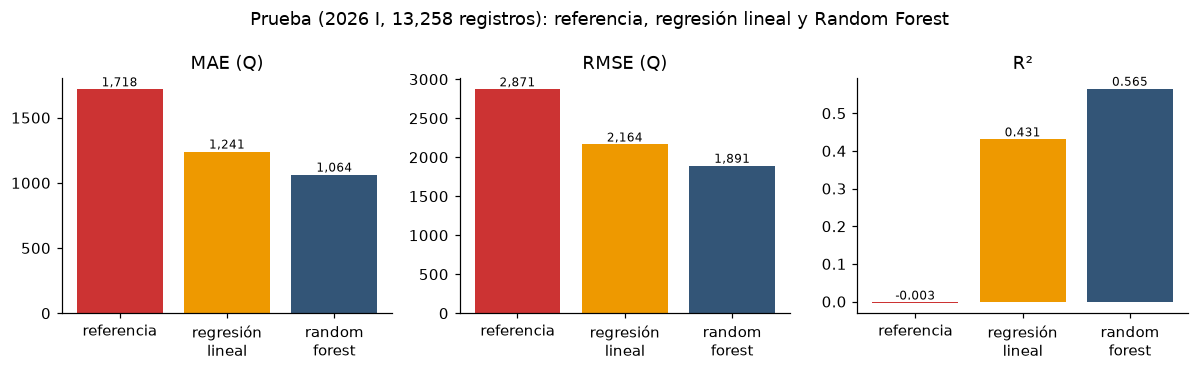

In [8]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 3.4))
colores = ["#c33", "#e90", "#357"]
etiquetas = ["referencia", "regresión\nlineal", "random\nforest"]
for eje, metrica, titulo in zip(ejes, ["mae", "rmse", "r2"], ["MAE (Q)", "RMSE (Q)", "R²"]):
    valores = tabla_prueba[metrica]
    eje.bar(etiquetas, valores, color=colores)
    for x, v in enumerate(valores):
        eje.annotate(f"{v:,.3f}" if metrica == "r2" else f"{v:,.0f}", (x, v), ha="center", va="bottom", fontsize=8)
    eje.set_title(titulo)
fig.suptitle(f"Prueba (2026 I, {pred.count():,} registros): referencia, regresión lineal y Random Forest")
fig.tight_layout()
fig.savefig(config.FIGURES / "07_metricas_prueba.png", bbox_inches="tight")
plt.show()

In [9]:
p = tabla_prueba.set_index("modelo")
ref, lin, rf = p.loc["referencia"], p.loc["regresión lineal"], p.loc["random forest"]
mejora = lambda a, b, m: 100 * (1 - a[m] / b[m])
ganador = "Random Forest" if rf["rmse"] < lin["rmse"] else "regresión lineal"

display(Markdown(f"""
**Lectura.**

- La referencia (predecir Q{media_ref:,.0f} a todos) tiene R² {ref['r2']:.3f}: no explica nada, como se esperaba.
- La **regresión lineal** baja el RMSE {mejora(lin, ref, 'rmse'):.1f} % y el MAE {mejora(lin, ref, 'mae'):.1f} % frente a la referencia, con R² {lin['r2']:.3f}.
- El **Random Forest** baja el RMSE **{mejora(rf, ref, 'rmse'):.1f} %** y el MAE **{mejora(rf, ref, 'mae'):.1f} %**, con R² **{rf['r2']:.3f}**.
- En 2026 el mejor modelo es el **{ganador}** en las tres métricas: frente a la regresión, el RMSE baja {mejora(rf, lin, 'rmse'):.1f} % (Q{lin['rmse']:,.0f} → Q{rf['rmse']:,.0f}) y el MAE {mejora(rf, lin, 'mae'):.1f} % (Q{lin['mae']:,.0f} → Q{rf['mae']:,.0f}).
- Aun así, el error típico del mejor modelo (MAE Q{rf['mae']:,.0f}) equivale a {100 * rf['mae'] / mediana_ref:.0f} % del salario mediano de 2025 (Q{mediana_ref:,.0f}), y el RMSE es {rf['rmse'] / rf['mae']:.1f} veces el MAE. Esa distancia entre RMSE y MAE indica que unos pocos errores muy grandes pesan mucho, lo que se analiza en la actividad 8.
"""))


**Lectura.**

- La referencia (predecir Q3,422 a todos) tiene R² -0.003: no explica nada, como se esperaba.
- La **regresión lineal** baja el RMSE 24.6 % y el MAE 27.8 % frente a la referencia, con R² 0.431.
- El **Random Forest** baja el RMSE **34.1 %** y el MAE **38.1 %**, con R² **0.565**.
- En 2026 el mejor modelo es el **Random Forest** en las tres métricas: frente a la regresión, el RMSE baja 12.6 % (Q2,164 → Q1,891) y el MAE 14.3 % (Q1,241 → Q1,064).
- Aun así, el error típico del mejor modelo (MAE Q1,064) equivale a 35 % del salario mediano de 2025 (Q3,000), y el RMSE es 1.8 veces el MAE. Esa distancia entre RMSE y MAE indica que unos pocos errores muy grandes pesan mucho, lo que se analiza en la actividad 8.


## 5. Validación (2025 IV) frente a prueba (2026 I)

Se compara el desempeño que cada configuración tuvo en validación, ajustada con 2025 I a III, con el que tiene en prueba, reentrenada con todo 2025. Si el error se mantiene, el modelo generaliza a un período nuevo; si sube mucho, la validación fue optimista o 2026 es distinto de 2025.

In [10]:
validacion_06 = pd.read_csv(config.TABLES / "06_comparacion_validacion.csv")
validacion_06["clave"] = ["referencia", "regresión lineal", "random forest"]
comparacion = validacion_06.set_index("clave")[["mae", "rmse", "r2"]].join(
    tabla_prueba.set_index("modelo")[["mae", "rmse", "r2"]], lsuffix="_validacion", rsuffix="_prueba")
for m in ["mae", "rmse"]:
    comparacion[f"cambio_{m}_pct"] = 100 * (comparacion[f"{m}_prueba"] / comparacion[f"{m}_validacion"] - 1)
comparacion["cambio_r2"] = comparacion["r2_prueba"] - comparacion["r2_validacion"]
comparacion.index.name = "modelo"
comparacion = comparacion.reset_index()
comparacion

,modelo,mae_validacion,rmse_validacion,r2_validacion,mae_prueba,rmse_prueba,r2_prueba,cambio_mae_pct,cambio_rmse_pct,cambio_r2
0,referencia,"1,672.503","2,889.571",-0.003,"1,718.086","2,871.421",-0.003,2.725,-0.628,0.001
1,regresión lineal,"1,210.137","2,186.420",0.426,"1,240.711","2,163.752",0.431,2.526,-1.037,0.005
2,random forest,"1,026.695","1,892.526",0.570,"1,063.684","1,891.371",0.565,3.603,-0.061,-0.005


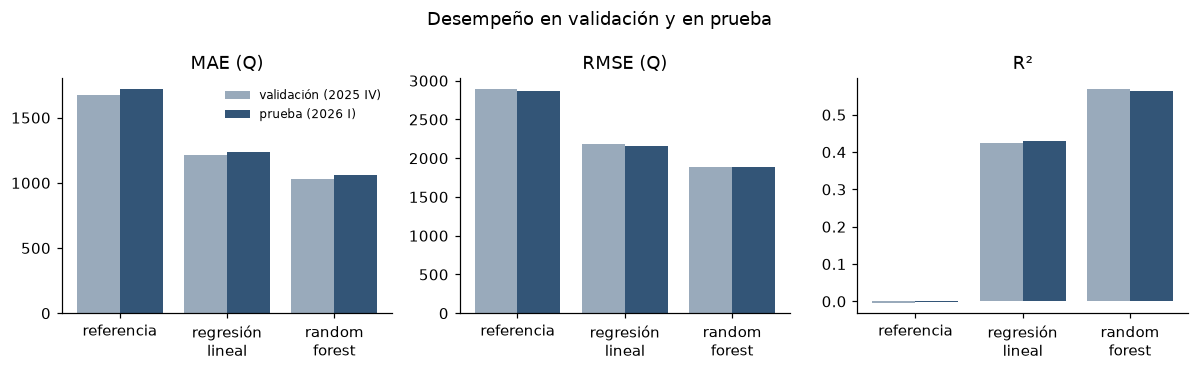

In [11]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 3.4))
pos = np.arange(len(comparacion))
for eje, metrica, titulo in zip(ejes, ["mae", "rmse", "r2"], ["MAE (Q)", "RMSE (Q)", "R²"]):
    eje.bar(pos - 0.2, comparacion[f"{metrica}_validacion"], width=0.4, color="#9ab", label="validación (2025 IV)")
    eje.bar(pos + 0.2, comparacion[f"{metrica}_prueba"], width=0.4, color="#357", label="prueba (2026 I)")
    eje.set_xticks(pos, ["referencia", "regresión\nlineal", "random\nforest"])
    eje.set_title(titulo)
ejes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Desempeño en validación y en prueba")
fig.tight_layout()
fig.savefig(config.FIGURES / "07_validacion_vs_prueba.png", bbox_inches="tight")
plt.show()

In [12]:
c = comparacion.set_index("modelo")
media_2026 = prueba.agg(F.avg(modelado.OBJETIVO)).first()[0]
mediana_2026 = prueba.approxQuantile(modelado.OBJETIVO, [0.5], 0.001)[0]

display(Markdown(f"""
**Lectura.**

- El RMSE de prueba cambia {c.loc['regresión lineal', 'cambio_rmse_pct']:+.1f} % en la regresión lineal y {c.loc['random forest', 'cambio_rmse_pct']:+.1f} % en el Random Forest frente a validación; el R² cambia {c.loc['regresión lineal', 'cambio_r2']:+.3f} y {c.loc['random forest', 'cambio_r2']:+.3f}. Los dos modelos **generalizan a 2026** con un desempeño muy parecido al de validación: la selección en 2025 IV no fue optimista.
- El MAE sube algo más ({c.loc['regresión lineal', 'cambio_mae_pct']:+.1f} % y {c.loc['random forest', 'cambio_mae_pct']:+.1f} %). En parte se debe a que los salarios de 2026 son algo más altos: media Q{media_2026:,.0f} y mediana Q{mediana_2026:,.0f}, frente a Q{media_ref:,.0f} y Q{mediana_ref:,.0f} en 2025. Un modelo ajustado con 2025 no sabe de ese cambio de nivel.
- El orden de los modelos se mantiene: **Random Forest < regresión lineal < referencia** en MAE y RMSE, igual que en validación.
"""))


**Lectura.**

- El RMSE de prueba cambia -1.0 % en la regresión lineal y -0.1 % en el Random Forest frente a validación; el R² cambia +0.005 y -0.005. Los dos modelos **generalizan a 2026** con un desempeño muy parecido al de validación: la selección en 2025 IV no fue optimista.
- El MAE sube algo más (+2.5 % y +3.6 %). En parte se debe a que los salarios de 2026 son algo más altos: media Q3,566 y mediana Q3,200, frente a Q3,422 y Q3,000 en 2025. Un modelo ajustado con 2025 no sabe de ese cambio de nivel.
- El orden de los modelos se mantiene: **Random Forest < regresión lineal < referencia** en MAE y RMSE, igual que en validación.


## 6. Guardado

Se guardan las tablas de la actividad en `results/tables/` y los dos pipelines finales en `results/modelos/` (`regresion_lineal_final` y `random_forest_final`, no se versionan).

In [13]:
tabla_prueba.to_csv(config.TABLES / "07_metricas_prueba_2026.csv", index=False)
comparacion.to_csv(config.TABLES / "07_validacion_vs_prueba.csv", index=False)
elegidas.to_csv(config.TABLES / "07_configuraciones_finales.csv", index=False)
try:
    rutas = evaluacion.guardar_modelos(modelos)
    print("Modelos guardados:", ", ".join(r.name for r in rutas))
except Exception as error:  # en Windows sin winutils (HADOOP_HOME) Spark no puede escribir modelos
    print("No se pudieron guardar los modelos:", type(error).__name__)
print("Tablas:", sorted(p.name for p in config.TABLES.glob("07_*.csv")))
print("Figuras:", sorted(p.name for p in config.FIGURES.glob("07_*.png")))

Modelos guardados: regresion_lineal_final, random_forest_final
Tablas: ['07_configuraciones_finales.csv', '07_metricas_prueba_2026.csv', '07_validacion_vs_prueba.csv']
Figuras: ['07_metricas_prueba.png', '07_validacion_vs_prueba.png']


## 7. Conclusión de la actividad

Cada algoritmo se reentrenó con los cuatro trimestres de 2025 usando la configuración que ganó en validación (sin regularización para la regresión lineal; 100 árboles de profundidad 20 para el Random Forest) y se evaluó una sola vez sobre los mismos registros elegibles del primer trimestre de 2026. El **Random Forest** vuelve a ser el mejor en MAE, RMSE y R², y las métricas de los dos modelos casi no cambian frente a validación, por lo que la comparación es estable entre períodos. Con los seis predictores del enunciado se explica algo más de la mitad de la variación del salario; el resto, y en particular los salarios más altos, queda sin explicar. La actividad 8 analiza dónde se concentran esos errores.